In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
import os
os.environ["KERAS_BACKEND"] = "jax"

import bayesflow as bf

INFO:2025-10-24 17:08:28,313:jax._src.xla_bridge:822: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
INFO:bayesflow:Using backend 'jax'


In [4]:
from simulators.benchmarks import DDM

In [6]:
num_obs = 500
num_train = 10000
num_val = 200
epochs = 500
batch_size = 32

### Workflow

In [7]:
simulator = DDM()

In [8]:
adapter = (
    bf.Adapter()
    .convert_dtype("float64", "float32")
    .drop(["decay"])
    .concatenate(["v", "a", "tau", "s_v", "s_tau"], axis=-1, into="inference_variables")
    .concatenate(["rts", "choices"], into="summary_variables")
)

In [9]:
summary_network = bf.networks.SetTransformer(summary_dim=16, seed_dim=32)
inference_network = bf.networks.FlowMatching()

In [10]:
workflow = bf.BasicWorkflow(
    inference_network=inference_network,
    summary_network=summary_network,
    simulator=simulator,
    adapter=adapter,
    checkpoint_filepath=f"../checkpoints/ddm_baseline_{num_obs}.ckpt",
)

In [11]:
train_set = workflow.simulate(num_train)
val_set = workflow.simulate(num_val)

In [12]:
history = workflow.fit_offline(
    data=train_set,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=val_set,
)

INFO:bayesflow:Fitting on dataset instance of OfflineDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/500
313/313 ━━━━━━━━━━━━━━━━━━━━ 45s 82ms/step - loss: 3.1853 - val_loss: 1.3412
Epoch 2/500
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.6658 - val_loss: 1.1219
Epoch 3/500
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 1.3612 - val_loss: 0.9937
Epoch 4/500
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 1.1712 - val_loss: 0.9515
Epoch 5/500
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.1082 - val_loss: 0.9610
Epoch 6/500
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 1.0376 - val_loss: 0.9390
Epoch 7/500
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 1.0061 - val_loss: 0.8848
Epoch 8/500
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.9569 - val_loss: 0.8896
Epoch 9/500
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.9404 - val_loss: 0.8591
Epoch 10/500
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.9267 - val_loss: 0.8076
Epoch 11/500
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.9018 - val_loss: 0.8499
Epoch 12/500
313/313 ━━━━━━━━━━━━━━━━━━

INFO:bayesflow:Training is now finished.
            You can find the trained approximator at '../checkpoints/ddm_baseline_500.ckpt/model.model.keras'.
            To load it, use approximator = keras.saving.load_model(...).


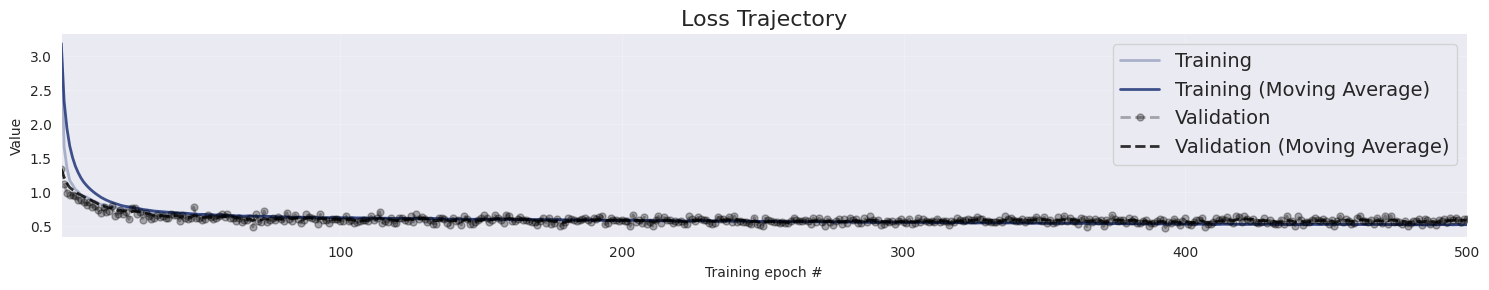

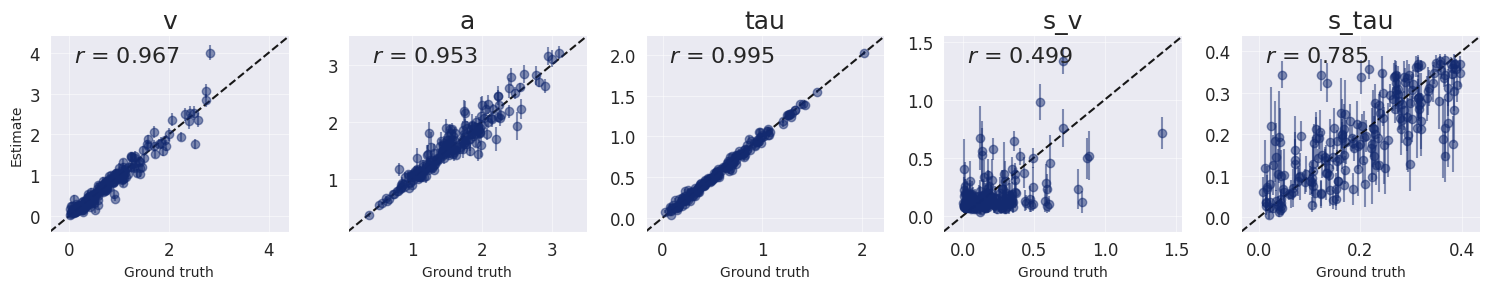

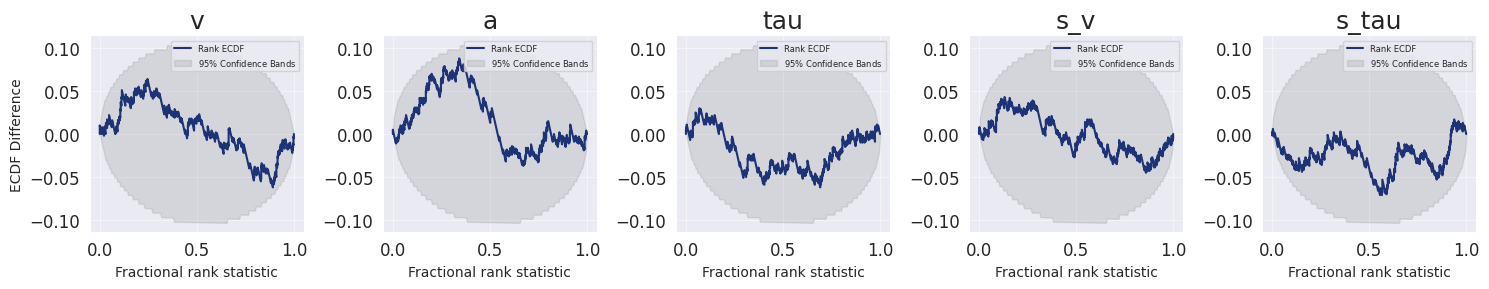

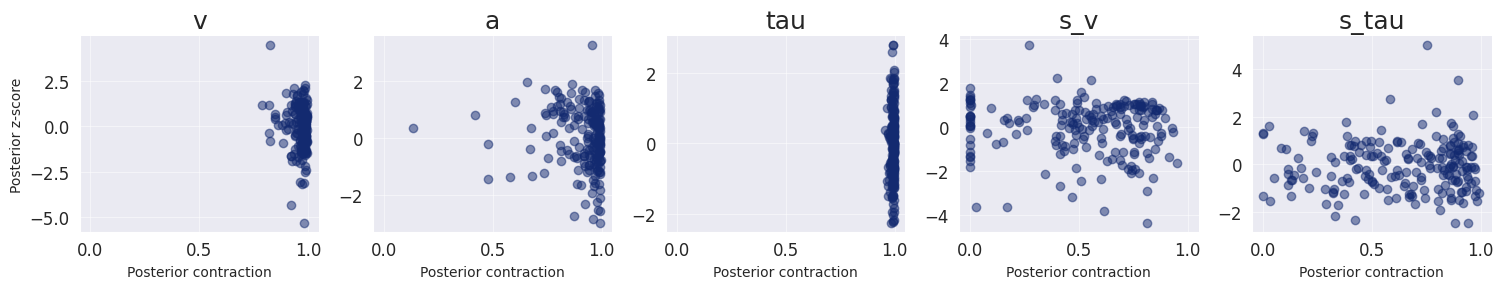

In [13]:
fig = workflow.plot_default_diagnostics(
    test_data=val_set,
    variable_names=["v", "a", "tau", "s_v", "s_tau"],
    num_samples=500,
    loss_kwargs={"figsize": (15, 3), "label_fontsize": 10},
    recovery_kwargs={"figsize": (15, 3), "label_fontsize": 10},
    calibration_ecdf_kwargs={"figsize": (15, 3), "legend_fontsize": 6, "difference": True, "label_fontsize": 10},
    z_score_contraction_kwargs={"figsize": (15, 3), "label_fontsize": 10}
)